# Transformers: The Mathematics of Attention

**A working notebook for someone who already has the intuition and wants the maths underneath it.**

---

## What this notebook covers

1. Why transformers exist — the problem with sequential models
2. The attention mechanism from first principles
3. Scaled dot-product attention — the core operation
4. Multi-head attention
5. Positional encoding
6. The full encoder architecture
7. Playing with it — interactive experiments

We'll build everything from scratch using NumPy, then verify against a minimal PyTorch implementation.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Optional: PyTorch for verification in the final section
try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
    print("PyTorch available — verification cells will run.")
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not found — NumPy-only mode. Verification cells will be skipped.")

np.random.seed(42)
plt.style.use('dark_background')
ACCENT = '#e05c5c'
print("Setup complete.")

PyTorch available — verification cells will run.
Setup complete.


---
## Part 1: Why Did We Need Transformers?

Before transformers (2017), the dominant architecture for sequence tasks was the **Recurrent Neural Network (RNN)** and its refined variant, the **LSTM**.

The core idea of an RNN is elegant: process a sequence one token at a time, maintaining a hidden state $h_t$ that carries information forward.

$$h_t = f(W_h h_{t-1} + W_x x_t + b)$$

where $x_t$ is the input at step $t$, $h_{t-1}$ is the previous hidden state, and $W_h$, $W_x$ are learned weight matrices.

**The problem: the information bottleneck.**

Everything the model knows about the past must be compressed into a single fixed-size vector $h_t$. For long sequences, early information gets diluted or lost. The maths of backpropagation through time (BPTT) makes this worse — gradients either vanish or explode as they propagate back through many timesteps.

$$\frac{\partial L}{\partial h_0} = \frac{\partial L}{\partial h_T} \prod_{t=1}^{T} \frac{\partial h_t}{\partial h_{t-1}}$$

If each $\frac{\partial h_t}{\partial h_{t-1}}$ has norm $< 1$, the product of $T$ such terms $\to 0$. The model literally cannot learn long-range dependencies.

**The second problem: no parallelism.**

Because step $t$ depends on step $t-1$, you cannot compute the sequence in parallel. Training is inherently sequential. At the scale of modern language modelling, this is a showstopper.

**The transformer's answer:** throw away recurrence entirely. Instead, let every position in the sequence attend directly to every other position, all at once, in parallel. The mechanism that does this is called **self-attention**.

---
## Part 2: The Attention Mechanism — The Core Idea

### 2.1 The intuition

Consider the sentence: *"The animal didn't cross the street because **it** was too tired."*

To understand what "it" refers to, a model needs to look at "animal" — not "street". Attention is the mechanism that learns *which other tokens to look at* when representing any given token.

### 2.2 The database analogy

Attention is often described as a soft, differentiable database lookup.

In a traditional key-value database:
- You have a **query** (what you're looking for)
- The database has **keys** (what each entry is indexed by)
- Each key is associated with a **value** (the actual content)
- You look up the query, find the matching key, return the value

Attention does the same thing, but:
- Instead of hard matching (found / not found), it computes a **similarity score** between the query and every key
- It returns a **weighted sum** of all values, where the weights come from those similarity scores
- Everything is differentiable, so it can be learned end-to-end

In a transformer, **queries, keys, and values are all derived from the same input** (the sequence itself) via learned linear projections. That's why it's called *self*-attention.

### 2.3 Where do Q, K, V come from?

Given an input sequence of $n$ tokens, each represented as a $d_{model}$-dimensional embedding vector, we form the matrix $X \in \mathbb{R}^{n \times d_{model}}$.

We then project $X$ three ways using learned weight matrices:

$$Q = X W^Q \quad \text{where } W^Q \in \mathbb{R}^{d_{model} \times d_k}$$
$$K = X W^K \quad \text{where } W^K \in \mathbb{R}^{d_{model} \times d_k}$$
$$V = X W^V \quad \text{where } W^V \in \mathbb{R}^{d_{model} \times d_v}$$

So:
- $Q \in \mathbb{R}^{n \times d_k}$ — one query vector per token
- $K \in \mathbb{R}^{n \times d_k}$ — one key vector per token
- $V \in \mathbb{R}^{n \times d_v}$ — one value vector per token

The weight matrices $W^Q, W^K, W^V$ are what the model learns. They determine *what kind of information* queries look for, what keys advertise, and what values contain.

In [2]:
# ── Let's build Q, K, V from scratch ──────────────────────────────────────────
#
# A toy sentence: 4 tokens, each represented as a 8-dimensional embedding.
# In practice d_model is 512 or 768 — we use 8 so we can see what's happening.

n_tokens = 4          # sequence length
d_model  = 8          # embedding dimension
d_k      = 4          # key/query dimension
d_v      = 4          # value dimension

# Pretend these are the embeddings for ["The", "cat", "sat", "down"]
X = np.random.randn(n_tokens, d_model)

# Learned projection matrices (randomly initialised here)
W_Q = np.random.randn(d_model, d_k) * 0.1
W_K = np.random.randn(d_model, d_k) * 0.1
W_V = np.random.randn(d_model, d_v) * 0.1

# Project
Q = X @ W_Q   # shape: (4, 4)
K = X @ W_K   # shape: (4, 4)
V = X @ W_V   # shape: (4, 4)

print(f"X shape:  {X.shape}  (n_tokens × d_model)")
print(f"Q shape:  {Q.shape}  (n_tokens × d_k)")
print(f"K shape:  {K.shape}  (n_tokens × d_k)")
print(f"V shape:  {V.shape}  (n_tokens × d_v)")
print()
print("Q (query matrix — one row per token):")
print(np.round(Q, 3))

X shape:  (4, 8)  (n_tokens × d_model)
Q shape:  (4, 4)  (n_tokens × d_k)
K shape:  (4, 4)  (n_tokens × d_k)
V shape:  (4, 4)  (n_tokens × d_v)

Q (query matrix — one row per token):
[[-0.342 -0.16  -0.083  0.128]
 [ 0.356 -0.127 -0.268 -0.256]
 [ 0.278 -0.116  0.135  0.107]
 [-0.177  0.061 -0.338 -0.141]]


---
## Part 3: Scaled Dot-Product Attention

### 3.1 The formula

This is the central equation of the transformer paper (Vaswani et al., 2017):

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Let's break this apart term by term.

---

### 3.2 Step 1: Compute similarity scores — $QK^T$

$Q \in \mathbb{R}^{n \times d_k}$ and $K^T \in \mathbb{R}^{d_k \times n}$, so:

$$QK^T \in \mathbb{R}^{n \times n}$$

This is an $n \times n$ matrix of raw similarity scores. Entry $(i, j)$ is the dot product between query $i$ and key $j$:

$$(QK^T)_{ij} = q_i \cdot k_j = \sum_{l=1}^{d_k} q_{il} \cdot k_{jl}$$

A high value means token $i$ finds token $j$ relevant. A low (or negative) value means low relevance.

---

### 3.3 Step 2: Scale — divide by $\sqrt{d_k}$

Why scale? The dot product's magnitude grows with $d_k$. If $q$ and $k$ are random vectors with unit variance components, then:

$$\text{Var}(q \cdot k) = \sum_{l=1}^{d_k} \text{Var}(q_l k_l) = d_k$$

So the standard deviation of raw dot products grows as $\sqrt{d_k}$. Large dot products push the softmax into regions where its gradient is nearly zero — the model stops learning. Dividing by $\sqrt{d_k}$ keeps the variance at 1 regardless of dimension.

---

### 3.4 Step 3: Softmax — convert scores to weights

The softmax is applied **row-wise** — independently for each query position $i$:

$$\text{softmax}(z_i)_j = \frac{e^{z_{ij}}}{\sum_{k=1}^{n} e^{z_{ik}}}$$

This maps each row of scores to a probability distribution over positions. The result is the **attention weight matrix** $A \in \mathbb{R}^{n \times n}$, where $A_{ij}$ is "how much position $i$ attends to position $j$".

Each row sums to 1. $A_{ij} \geq 0$. Think of it as: for token $i$, what fraction of its attention should go to each other token?

---

### 3.5 Step 4: Weight the values — multiply by $V$

$$\text{Output} = A \cdot V \in \mathbb{R}^{n \times d_v}$$

Row $i$ of the output is a weighted sum of all value vectors, where the weights are attention weights from row $i$ of $A$:

$$\text{output}_i = \sum_{j=1}^{n} A_{ij} \cdot v_j$$

This is the key operation: each token's output is assembled by pulling in information from every other token, weighted by relevance.

In [3]:
# ── Implementing scaled dot-product attention ──────────────────────────────────

def softmax(x, axis=-1):
    """Numerically stable softmax."""
    # Subtract max for numerical stability (prevents overflow in exp)
    x_shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Computes Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V
    
    Args:
        Q: (n, d_k)
        K: (n, d_k)
        V: (n, d_v)
        mask: optional (n, n) boolean mask — True = mask out (for causal attention)
    
    Returns:
        output: (n, d_v)
        attention_weights: (n, n)
    """
    d_k = Q.shape[-1]
    
    # Step 1: Raw scores
    scores = Q @ K.T          # (n, n)
    
    # Step 2: Scale
    scores = scores / np.sqrt(d_k)
    
    # Step 3: Optional mask (used in decoder to prevent attending to future tokens)
    if mask is not None:
        scores = np.where(mask, -1e9, scores)
    
    # Step 4: Softmax
    attention_weights = softmax(scores, axis=-1)  # (n, n)
    
    # Step 5: Weight the values
    output = attention_weights @ V                 # (n, d_v)
    
    return output, attention_weights

# Run on our toy Q, K, V
output, attn_weights = scaled_dot_product_attention(Q, K, V)

print(f"Output shape: {output.shape}  (n_tokens × d_v)")
print(f"Attention weights shape: {attn_weights.shape}  (n_tokens × n_tokens)")
print()
print("Attention weight matrix (each row sums to 1):")
print(np.round(attn_weights, 3))
print()
print("Row sums (should all be 1.0):")
print(np.round(attn_weights.sum(axis=1), 6))

Output shape: (4, 4)  (n_tokens × d_v)
Attention weights shape: (4, 4)  (n_tokens × n_tokens)

Attention weight matrix (each row sums to 1):
[[0.25  0.242 0.254 0.254]
 [0.254 0.262 0.224 0.26 ]
 [0.236 0.257 0.262 0.245]
 [0.27  0.247 0.227 0.256]]

Row sums (should all be 1.0):
[1. 1. 1. 1.]


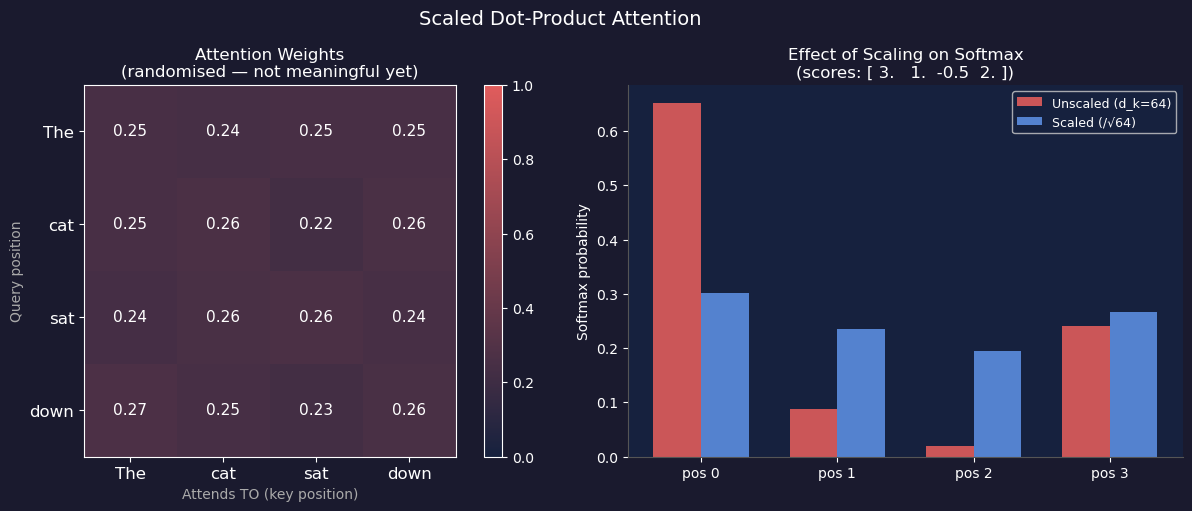


Unscaled softmax (sharper, winner-takes-all): [0.652 0.088 0.02  0.24 ]
Scaled softmax   (softer, more distributed):  [0.302 0.236 0.195 0.267]

Note: Unscaled pushes probability to a single position — gradients vanish elsewhere.


In [4]:
# ── Visualise the attention weight matrix ──────────────────────────────────────

tokens = ["The", "cat", "sat", "down"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#1a1a2e')

# Attention heatmap
ax = axes[0]
ax.set_facecolor('#16213e')
cmap = LinearSegmentedColormap.from_list('attn', ['#16213e', '#e05c5c'])
im = ax.imshow(attn_weights, cmap=cmap, vmin=0, vmax=1)
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, color='white', fontsize=12)
ax.set_yticklabels(tokens, color='white', fontsize=12)
ax.set_xlabel("Attends TO (key position)", color='#aaa', fontsize=10)
ax.set_ylabel("Query position", color='#aaa', fontsize=10)
ax.set_title("Attention Weights\n(randomised — not meaningful yet)", color='white', fontsize=12)
for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax.text(j, i, f"{attn_weights[i,j]:.2f}",
                ha='center', va='center', color='white', fontsize=11)
plt.colorbar(im, ax=ax)

# Show the scaling effect on softmax
ax2 = axes[1]
ax2.set_facecolor('#16213e')
d_k_test = 64
raw_scores = np.array([3.0, 1.0, -0.5, 2.0])  # some example scores

scaled_scores   = raw_scores / np.sqrt(d_k_test)
unscaled_probs  = softmax(raw_scores)
scaled_probs    = softmax(scaled_scores)

x = np.arange(4)
w = 0.35
bars1 = ax2.bar(x - w/2, unscaled_probs, w, label=f'Unscaled (d_k={d_k_test})', color=ACCENT, alpha=0.9)
bars2 = ax2.bar(x + w/2, scaled_probs, w, label=f'Scaled (/√{d_k_test})', color='#5c8de0', alpha=0.9)
ax2.set_xticks(x)
ax2.set_xticklabels([f'pos {i}' for i in range(4)], color='white')
ax2.set_ylabel('Softmax probability', color='white')
ax2.set_title(f'Effect of Scaling on Softmax\n(scores: {raw_scores})', color='white', fontsize=12)
ax2.tick_params(colors='white')
ax2.legend(facecolor='#16213e', labelcolor='white', fontsize=9)
ax2.spines['bottom'].set_color('#555')
ax2.spines['left'].set_color('#555')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.suptitle('Scaled Dot-Product Attention', color='white', fontsize=14, y=1.02)
plt.savefig('attention_viz.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print(f"\nUnscaled softmax (sharper, winner-takes-all): {np.round(unscaled_probs, 3)}")
print(f"Scaled softmax   (softer, more distributed):  {np.round(scaled_probs, 3)}")
print("\nNote: Unscaled pushes probability to a single position — gradients vanish elsewhere.")

---
## Part 4: Multi-Head Attention

### 4.1 The problem with single-head attention

A single attention head learns one type of relationship. In a sentence like *"John gave Mary the book"*, a model might need to simultaneously track:
- syntactic dependencies (subject-verb, verb-object)
- coreference (which noun does a pronoun refer to?)
- semantic proximity (which words are about similar concepts?)

A single set of Q, K, V projections can't easily represent all of these at once.

### 4.2 The solution: run attention $h$ times in parallel

Multi-head attention runs $h$ independent attention heads, each with its own projection matrices:

$$\text{head}_i = \text{Attention}(QW_i^Q,\; KW_i^K,\; VW_i^V)$$

where $W_i^Q \in \mathbb{R}^{d_{model} \times d_k}$, $W_i^K \in \mathbb{R}^{d_{model} \times d_k}$, $W_i^V \in \mathbb{R}^{d_{model} \times d_v}$.

By convention (from the original paper), $d_k = d_v = d_{model} / h$, so the total computation is similar to single-head attention at full dimension.

The $h$ head outputs are concatenated, then projected back down:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)\; W^O$$

where $W^O \in \mathbb{R}^{h \cdot d_v \times d_{model}}$ is a final learned projection.

### 4.3 Why does this work?

Each head is free to learn a different subspace of the representation. In practice, different heads do specialise — some attend to adjacent tokens, some to syntactically related tokens, some to semantically similar ones. The concatenation + projection then combines all these signals.

The dimension reduction ($d_{model} \to d_k = d_{model}/h$ per head) means:
- Each head operates on a lower-dimensional projection — forcing it to be selective
- Total parameters stay similar to single-head at full dimension
- Computation is parallelisable across heads

In [5]:
# ── Multi-head attention from scratch ─────────────────────────────────────────

class MultiHeadAttention:
    """
    Multi-head attention in NumPy.
    
    d_model: total embedding dimension
    h:       number of heads
    d_k = d_v = d_model // h  (per head dimension)
    """
    def __init__(self, d_model, h):
        assert d_model % h == 0, "d_model must be divisible by h"
        self.d_model = d_model
        self.h       = h
        self.d_k     = d_model // h  # dimension per head
        
        # Weight matrices for all heads — packed together for efficiency
        # W_Q: (d_model, h * d_k) = (d_model, d_model)
        scale = np.sqrt(2.0 / (d_model + self.d_k))
        self.W_Q = np.random.randn(d_model, d_model) * scale
        self.W_K = np.random.randn(d_model, d_model) * scale
        self.W_V = np.random.randn(d_model, d_model) * scale
        self.W_O = np.random.randn(d_model, d_model) * scale  # output projection
    
    def forward(self, X, mask=None, return_weights=False):
        """
        X: (n, d_model)
        Returns: (n, d_model), and optionally attention weights per head
        """
        n = X.shape[0]
        
        # Project to Q, K, V (full dimension)
        Q_full = X @ self.W_Q  # (n, d_model)
        K_full = X @ self.W_K
        V_full = X @ self.W_V
        
        # Split into h heads: reshape to (h, n, d_k)
        Q_heads = Q_full.reshape(n, self.h, self.d_k).transpose(1, 0, 2)  # (h, n, d_k)
        K_heads = K_full.reshape(n, self.h, self.d_k).transpose(1, 0, 2)
        V_heads = V_full.reshape(n, self.h, self.d_k).transpose(1, 0, 2)
        
        # Apply attention independently per head
        head_outputs = []
        all_weights  = []
        for i in range(self.h):
            out, weights = scaled_dot_product_attention(
                Q_heads[i], K_heads[i], V_heads[i], mask
            )
            head_outputs.append(out)      # each: (n, d_k)
            all_weights.append(weights)   # each: (n, n)
        
        # Concatenate heads: (n, h * d_k) = (n, d_model)
        concat = np.concatenate(head_outputs, axis=-1)
        
        # Final linear projection
        output = concat @ self.W_O  # (n, d_model)
        
        if return_weights:
            return output, np.stack(all_weights)  # weights: (h, n, n)
        return output


# ── Try it ──
d_model = 16
h       = 4
n       = 6  # 6-token sequence

mha = MultiHeadAttention(d_model=d_model, h=h)
X_test = np.random.randn(n, d_model)

out, weights = mha.forward(X_test, return_weights=True)

print(f"Input shape:  {X_test.shape}")
print(f"Output shape: {out.shape}  (same shape — input dimension preserved)")
print(f"Weight shape: {weights.shape}  (h heads × n × n)")
print(f"\nd_k per head: {d_model // h} (= d_model / h = {d_model}/{h})")
print(f"Total projected dim: h × d_k = {h} × {d_model//h} = {d_model} ✓")

Input shape:  (6, 16)
Output shape: (6, 16)  (same shape — input dimension preserved)
Weight shape: (4, 6, 6)  (h heads × n × n)

d_k per head: 4 (= d_model / h = 16/4)
Total projected dim: h × d_k = 4 × 4 = 16 ✓


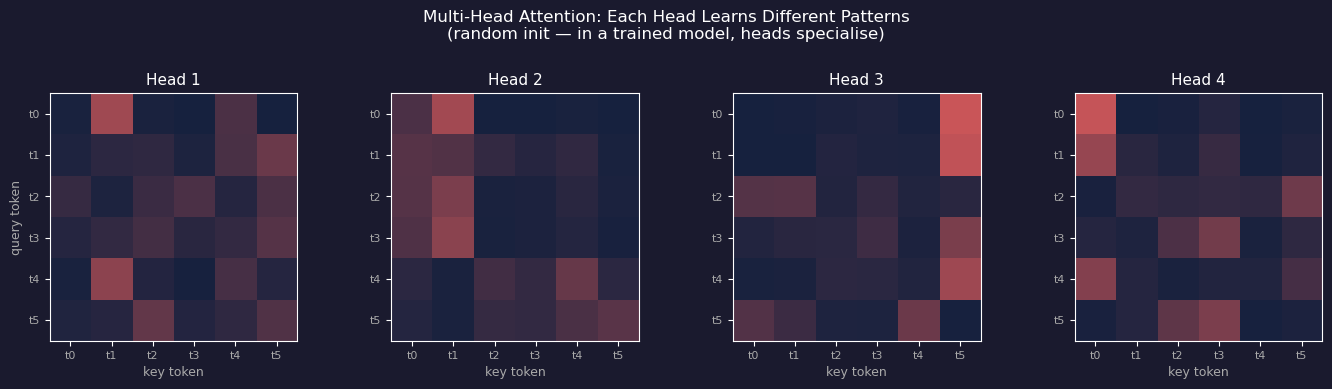

In [6]:
# ── Visualise all 4 heads' attention patterns ──────────────────────────────────

fig, axes = plt.subplots(1, h, figsize=(14, 3.5))
fig.patch.set_facecolor('#1a1a2e')
cmap = LinearSegmentedColormap.from_list('attn', ['#16213e', '#e05c5c'])
labels = [f't{i}' for i in range(n)]

for i, ax in enumerate(axes):
    ax.set_facecolor('#16213e')
    im = ax.imshow(weights[i], cmap=cmap, vmin=0, vmax=1)
    ax.set_title(f'Head {i+1}', color='white', fontsize=11)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, color='#aaa', fontsize=8)
    ax.set_yticklabels(labels, color='#aaa', fontsize=8)
    if i == 0:
        ax.set_ylabel('query token', color='#aaa', fontsize=9)
    ax.set_xlabel('key token', color='#aaa', fontsize=9)

plt.suptitle('Multi-Head Attention: Each Head Learns Different Patterns\n'
             '(random init — in a trained model, heads specialise)', 
             color='white', fontsize=12, y=1.05)
plt.tight_layout()
plt.savefig('multihead_viz.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## Part 5: Positional Encoding

### 5.1 The problem attention creates

Attention is **permutation-equivariant**. If you shuffle the input tokens, the output is shuffled in exactly the same way — the model has no idea about order.

Formally: if $\pi$ is a permutation matrix, then:
$$\text{Attention}(\pi Q, \pi K, \pi V) = \pi \cdot \text{Attention}(Q, K, V)$$

For language (and most sequences), order is everything. "Dog bites man" ≠ "Man bites dog".

### 5.2 The solution: inject position information

The original transformer adds a **positional encoding** $PE$ directly to the token embeddings before they enter the attention layers:

$$X_{input} = X_{embedding} + PE$$

The encoding $PE \in \mathbb{R}^{n \times d_{model}}$ assigns a unique vector to each position. The formula uses sine and cosine functions at different frequencies:

$$PE_{(pos, 2i)}   = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

where $pos$ is the position in the sequence and $i$ is the dimension index.

### 5.3 Why sinusoids?

Several nice properties:

1. **Unique**: Every position gets a unique encoding — no two positions have the same vector.

2. **Bounded**: All values in $[-1, 1]$, so it doesn't swamp the embeddings.

3. **Relative positions are representable**: For any fixed offset $k$, $PE_{pos+k}$ can be expressed as a linear function of $PE_{pos}$. This follows from the angle addition formula:
   $$\sin(A + B) = \sin A \cos B + \cos A \sin B$$
   So a fixed offset $k$ corresponds to a fixed linear transformation — the model can learn to recognise relative distances.

4. **Generalises to longer sequences**: Because it's a formula, not a lookup table, it works for sequences longer than those seen during training.

Different dimensions capture different frequency scales — lower dimensions oscillate slowly (coarse position), higher dimensions oscillate rapidly (fine position). Think of it like a binary number: each bit position flips at a different rate, and together they encode any number.

PE shape: (50, 64)
All values in [-1, 1]: -1.000 to 1.000


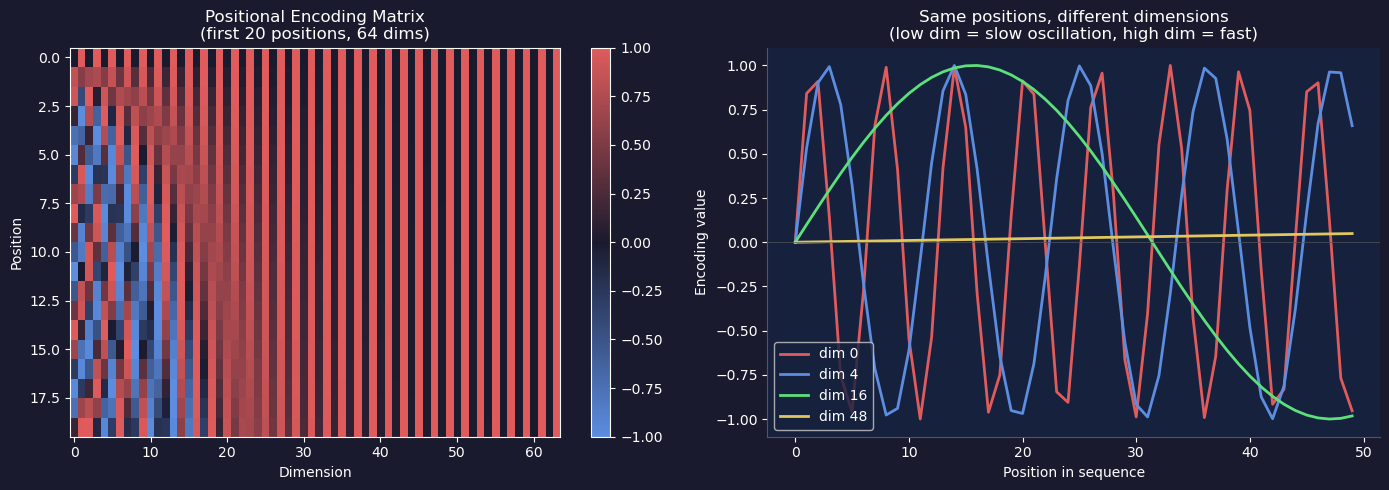

In [7]:
# ── Positional encoding ────────────────────────────────────────────────────────

def positional_encoding(max_len, d_model):
    """
    Compute the sinusoidal positional encoding matrix.
    Returns: PE of shape (max_len, d_model)
    """
    PE = np.zeros((max_len, d_model))
    
    positions = np.arange(max_len)[:, np.newaxis]    # (max_len, 1)
    dims      = np.arange(0, d_model, 2)             # even indices: 0, 2, 4, ...
    
    # The frequency term: 1 / 10000^(2i/d_model)
    frequencies = 1.0 / (10000 ** (dims / d_model))  # (d_model/2,)
    
    angles = positions * frequencies  # (max_len, d_model/2)
    
    PE[:, 0::2] = np.sin(angles)  # even dimensions
    PE[:, 1::2] = np.cos(angles)  # odd dimensions
    
    return PE


# Generate for 50 positions, 64 dimensions
PE = positional_encoding(max_len=50, d_model=64)
print(f"PE shape: {PE.shape}")
print(f"All values in [-1, 1]: {PE.min():.3f} to {PE.max():.3f}")

# ── Visualise ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')

# Full heatmap
ax = axes[0]
ax.set_facecolor('#16213e')
cmap2 = LinearSegmentedColormap.from_list('pe', ['#5c8de0', '#1a1a2e', '#e05c5c'])
im = ax.imshow(PE[:20, :], aspect='auto', cmap=cmap2, vmin=-1, vmax=1)
ax.set_xlabel('Dimension', color='white')
ax.set_ylabel('Position', color='white')
ax.set_title('Positional Encoding Matrix\n(first 20 positions, 64 dims)', color='white')
ax.tick_params(colors='white')
plt.colorbar(im, ax=ax)

# Individual dimensions to show different frequencies
ax2 = axes[1]
ax2.set_facecolor('#16213e')
positions = np.arange(50)
colours = ['#e05c5c', '#5c8de0', '#5ce07a', '#e0c85c']
for idx, (dim, colour) in enumerate(zip([0, 4, 16, 48], colours)):
    ax2.plot(positions, PE[:, dim], label=f'dim {dim}', color=colour, linewidth=2)
ax2.set_xlabel('Position in sequence', color='white')
ax2.set_ylabel('Encoding value', color='white')
ax2.set_title('Same positions, different dimensions\n(low dim = slow oscillation, high dim = fast)', color='white')
ax2.tick_params(colors='white')
ax2.legend(facecolor='#16213e', labelcolor='white')
ax2.spines['bottom'].set_color('#555')
ax2.spines['left'].set_color('#555')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.axhline(0, color='#555', linewidth=0.5)

plt.tight_layout()
plt.savefig('positional_encoding.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [8]:
# ── Verify that relative positions are linearly related ────────────────────────
#
# The claim: PE(pos + k) is a linear transformation of PE(pos).
# We can check this numerically by seeing how well we can predict
# PE(pos + 5) from PE(pos) using a linear model.

from numpy.linalg import lstsq

PE_long = positional_encoding(max_len=100, d_model=64)
k = 5  # fixed offset

# Use positions 0..79 as source, 5..84 as target
X_src = PE_long[:80]   # (80, 64)
X_tgt = PE_long[k:80+k]  # (80, 64)

# Fit a linear map: X_src @ M ≈ X_tgt
M, residuals, rank, sv = lstsq(X_src, X_tgt, rcond=None)

# How well does it reconstruct?
X_pred = X_src @ M
reconstruction_error = np.mean((X_pred - X_tgt) ** 2)

print(f"Offset k = {k}")
print(f"Linear map shape: {M.shape}")
print(f"Mean squared reconstruction error: {reconstruction_error:.2e}")
print()
if reconstruction_error < 1e-8:
    print("✓ Near-perfect reconstruction — PE(pos+k) IS a linear transform of PE(pos)")
    print("  This means the model can learn relative position from the encodings.")
else:
    print(f"  Error: {reconstruction_error:.6f}")

Offset k = 5
Linear map shape: (64, 64)
Mean squared reconstruction error: 1.38e-29

✓ Near-perfect reconstruction — PE(pos+k) IS a linear transform of PE(pos)
  This means the model can learn relative position from the encodings.


---
## Part 6: The Full Encoder Architecture

### 6.1 Overview

The original transformer has an **encoder** (for understanding input) and a **decoder** (for generating output). For many modern applications (BERT, RoBERTa, most classification tasks) only the encoder is used. We'll build a single encoder layer here.

One encoder layer contains:

```
Input embeddings + Positional encoding
          │
          ▼
┌─────────────────────────┐
│   Multi-Head Attention   │
│       (self-attention)   │
└──────────┬──────────────┘
           │
     Residual add + LayerNorm
           │
┌──────────▼──────────────┐
│  Feed-Forward Network    │
│  (two linear layers)     │
└──────────┬──────────────┘
           │
     Residual add + LayerNorm
           │
          ▼
       Output
```

A full transformer encoder stacks $N$ of these layers (the original paper uses $N = 6$).

### 6.2 The two new components: residual connections + layer norm

**Residual connections** (from ResNet, 2015):

$$\text{output} = \text{LayerNorm}(x + \text{Sublayer}(x))$$

Rather than the sublayer replacing the input, we *add the input back*. This creates a direct gradient path from later layers to earlier ones, solving the vanishing gradient problem for depth. The sublayer only needs to learn the *residual* (the correction) rather than a full transformation.

**Layer normalisation** stabilises training by normalising across the feature dimension for each token independently:

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sigma + \epsilon} + \beta$$

where $\mu$ and $\sigma$ are the mean and standard deviation computed across the $d_{model}$ features of a single token, and $\gamma, \beta$ are learned scale and shift parameters.

This is different from batch normalisation (which normalises across the batch). Layer norm works on a single sequence at a time — essential for variable-length sequences and autoregressive generation.

### 6.3 The Feed-Forward Network (FFN)

After attention, each position passes through an identical two-layer MLP:

$$\text{FFN}(x) = \text{ReLU}(x W_1 + b_1) W_2 + b_2$$

where $W_1 \in \mathbb{R}^{d_{model} \times d_{ff}}$ and $W_2 \in \mathbb{R}^{d_{ff} \times d_{model}}$.

Typically $d_{ff} = 4 \times d_{model}$ — a wide bottleneck. The FFN is applied identically to every position (no interaction between positions — that's what attention is for). It's often thought of as where the model "thinks" per-token after gathering information via attention.

In [9]:
# ── Building the full encoder layer ───────────────────────────────────────────

def layer_norm(x, gamma, beta, eps=1e-6):
    """
    Layer normalisation: normalise across feature dimension per token.
    x:     (n, d_model)
    gamma: (d_model,)  — learned scale
    beta:  (d_model,)  — learned shift
    """
    mu    = x.mean(axis=-1, keepdims=True)                       # (n, 1)
    sigma = x.std(axis=-1, keepdims=True)                        # (n, 1)
    x_hat = (x - mu) / (sigma + eps)                             # (n, d_model)
    return gamma * x_hat + beta


def relu(x):
    return np.maximum(0, x)


class FeedForward:
    """
    FFN(x) = ReLU(x W1 + b1) W2 + b2
    d_ff is the inner dimension, typically 4 * d_model
    """
    def __init__(self, d_model, d_ff):
        scale = np.sqrt(2.0 / d_model)
        self.W1 = np.random.randn(d_model, d_ff)  * scale
        self.b1 = np.zeros(d_ff)
        self.W2 = np.random.randn(d_ff, d_model)  * scale
        self.b2 = np.zeros(d_model)
    
    def forward(self, x):
        return relu(x @ self.W1 + self.b1) @ self.W2 + self.b2


class EncoderLayer:
    """
    One transformer encoder layer:
      x -> MHA -> add & norm -> FFN -> add & norm
    """
    def __init__(self, d_model, h, d_ff):
        self.mha = MultiHeadAttention(d_model, h)
        self.ffn = FeedForward(d_model, d_ff)
        # LayerNorm parameters (two sets: after attention, after FFN)
        self.gamma1 = np.ones(d_model)
        self.beta1  = np.zeros(d_model)
        self.gamma2 = np.ones(d_model)
        self.beta2  = np.zeros(d_model)
    
    def forward(self, x, mask=None):
        """
        x: (n, d_model)
        """
        # Sub-layer 1: Multi-Head Attention + residual + layer norm
        attn_out = self.mha.forward(x, mask=mask)          # (n, d_model)
        x = layer_norm(x + attn_out, self.gamma1, self.beta1)  # residual!
        
        # Sub-layer 2: FFN + residual + layer norm
        ffn_out = self.ffn.forward(x)                      # (n, d_model)
        x = layer_norm(x + ffn_out, self.gamma2, self.beta2)   # residual!
        
        return x


class TransformerEncoder:
    """Stack of N encoder layers."""
    def __init__(self, d_model, h, d_ff, n_layers, max_len=512):
        self.d_model = d_model
        self.PE      = positional_encoding(max_len, d_model)
        self.layers  = [EncoderLayer(d_model, h, d_ff) for _ in range(n_layers)]
    
    def forward(self, X, mask=None):
        """
        X: (n, d_model) — already-embedded tokens
        """
        n = X.shape[0]
        # Add positional encoding
        x = X + self.PE[:n]
        # Pass through each encoder layer
        for layer in self.layers:
            x = layer.forward(x, mask)
        return x


# ── Run the full encoder ──
d_model  = 64
h        = 8
d_ff     = 256   # 4 * d_model
n_layers = 6     # as in the original paper
n_tokens = 10

encoder = TransformerEncoder(d_model=d_model, h=h, d_ff=d_ff, n_layers=n_layers)
X_in    = np.random.randn(n_tokens, d_model)
X_out   = encoder.forward(X_in)

print(f"Input:  {X_in.shape}")
print(f"Output: {X_out.shape}  (same shape — encoder preserves dimensions)")
print()
print(f"Architecture summary:")
print(f"  Layers:           {n_layers}")
print(f"  d_model:          {d_model}")
print(f"  Attention heads:  {h}  (each head: d_k={d_model//h})")
print(f"  FFN inner dim:    {d_ff}")

# Count parameters
params_per_mha = 4 * d_model * d_model           # W_Q, W_K, W_V, W_O
params_per_ffn = d_model * d_ff + d_ff * d_model # W1, W2 (ignoring biases)
params_per_ln  = 2 * d_model * 2                 # gamma+beta, two LN per layer
total_params   = n_layers * (params_per_mha + params_per_ffn + params_per_ln)
print(f"\nApproximate parameter count:")
print(f"  Per-layer (MHA):  {params_per_mha:,}")
print(f"  Per-layer (FFN):  {params_per_ffn:,}")
print(f"  Total ({n_layers} layers): {total_params:,}")
print(f"  (GPT-3 has 175 billion parameters. d_model=12288, h=96, n_layers=96)")

Input:  (10, 64)
Output: (10, 64)  (same shape — encoder preserves dimensions)

Architecture summary:
  Layers:           6
  d_model:          64
  Attention heads:  8  (each head: d_k=8)
  FFN inner dim:    256

Approximate parameter count:
  Per-layer (MHA):  16,384
  Per-layer (FFN):  32,768
  Total (6 layers): 296,448
  (GPT-3 has 175 billion parameters. d_model=12288, h=96, n_layers=96)


---
## Part 7: The Causal Mask (Decoder Detail)

The encoder can attend to all positions freely. But in a **decoder** (used for generation), token $t$ must not be allowed to look at token $t+1, t+2, ...$  — those are the future tokens it's trying to predict.

This is enforced with a **causal mask**: an upper-triangular boolean matrix where `True` means "mask this position out" (set to $-\infty$ before softmax).

$$M_{ij} = \begin{cases} 0 & \text{if } j \leq i \\ -\infty & \text{if } j > i \end{cases}$$

After softmax, $e^{-\infty} = 0$, so masked positions get zero attention weight.

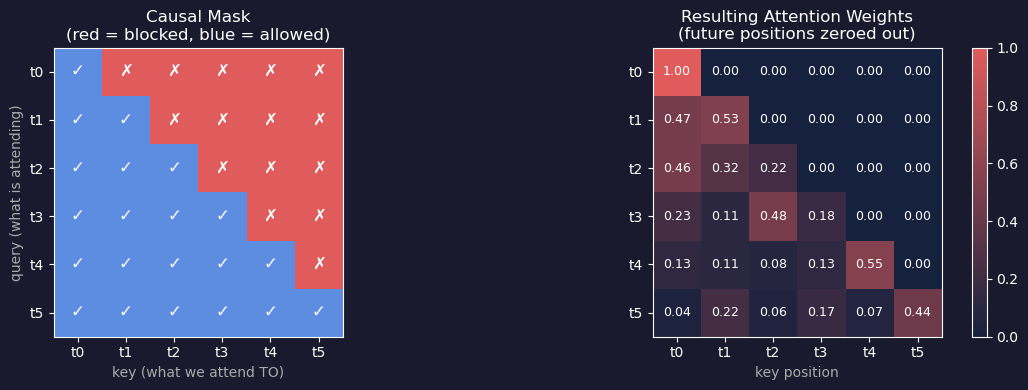

Notice: the lower triangle is a valid probability distribution per row.
Token t0 only attends to itself. Token t5 can attend to all 6 positions.


In [10]:
# ── Causal mask ────────────────────────────────────────────────────────────────

def make_causal_mask(n):
    """
    Returns an (n, n) boolean mask.
    True  = "this attention connection is blocked"
    Upper triangle (future positions) → True
    Diagonal and lower → False (can attend)
    """
    # np.triu gives upper triangle; k=1 excludes the diagonal
    return np.triu(np.ones((n, n), dtype=bool), k=1)

n = 6
mask = make_causal_mask(n)

# ── Visualise ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#1a1a2e')
token_labels = [f't{i}' for i in range(n)]

# The mask
ax = axes[0]
ax.set_facecolor('#16213e')
cmap_mask = LinearSegmentedColormap.from_list('mask', ['#5c8de0', '#e05c5c'])
im = ax.imshow(mask.astype(float), cmap=cmap_mask, vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(token_labels, color='white')
ax.set_yticklabels(token_labels, color='white')
ax.set_title('Causal Mask\n(red = blocked, blue = allowed)', color='white')
ax.set_xlabel('key (what we attend TO)', color='#aaa')
ax.set_ylabel('query (what is attending)', color='#aaa')
for i in range(n):
    for j in range(n):
        ax.text(j, i, '✗' if mask[i,j] else '✓', ha='center', va='center',
                color='white', fontsize=12)

# Masked attention weights
Q_c, K_c, V_c = np.random.randn(n, 8), np.random.randn(n, 8), np.random.randn(n, 8)
_, masked_weights = scaled_dot_product_attention(Q_c, K_c, V_c, mask=mask)

ax2 = axes[1]
ax2.set_facecolor('#16213e')
cmap_attn = LinearSegmentedColormap.from_list('attn', ['#16213e', '#e05c5c'])
im2 = ax2.imshow(masked_weights, cmap=cmap_attn, vmin=0, vmax=1)
ax2.set_xticks(range(n))
ax2.set_yticks(range(n))
ax2.set_xticklabels(token_labels, color='white')
ax2.set_yticklabels(token_labels, color='white')
ax2.set_title('Resulting Attention Weights\n(future positions zeroed out)', color='white')
ax2.set_xlabel('key position', color='#aaa')
for i in range(n):
    for j in range(n):
        ax2.text(j, i, f"{masked_weights[i,j]:.2f}", ha='center', va='center',
                 color='white', fontsize=9)
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.savefig('causal_mask.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Notice: the lower triangle is a valid probability distribution per row.")
print("Token t0 only attends to itself. Token t5 can attend to all 6 positions.")

---
## Part 8: PyTorch Verification

Let's verify our NumPy implementation produces the same attention weight structure as PyTorch's `nn.MultiheadAttention`.

In [11]:
if not TORCH_AVAILABLE:
    print("PyTorch not available — skipping verification.")
    print("Install with: pip install torch --index-url https://download.pytorch.org/whl/cpu")
else:
    # ── Verify scaled dot-product attention in PyTorch ─────────────────────────
    import torch.nn.functional as F
    
    n, d_k = 5, 8
    np.random.seed(0)
    Q_np = np.random.randn(n, d_k).astype(np.float32)
    K_np = np.random.randn(n, d_k).astype(np.float32)
    V_np = np.random.randn(n, d_k).astype(np.float32)

    # NumPy
    out_np, weights_np = scaled_dot_product_attention(Q_np, K_np, V_np)

    # PyTorch
    Q_t = torch.from_numpy(Q_np)
    K_t = torch.from_numpy(K_np)
    V_t = torch.from_numpy(V_np)

    # Manual PyTorch version (matching our formula)
    scores_t = (Q_t @ K_t.T) / np.sqrt(d_k)
    weights_t = torch.softmax(scores_t, dim=-1)
    out_t = weights_t @ V_t

    max_diff_weights = np.abs(weights_np - weights_t.numpy()).max()
    max_diff_output  = np.abs(out_np - out_t.numpy()).max()

    print("NumPy vs PyTorch comparison:")
    print(f"  Max difference in attention weights: {max_diff_weights:.2e}")
    print(f"  Max difference in output:            {max_diff_output:.2e}")
    
    if max_diff_weights < 1e-5 and max_diff_output < 1e-5:
        print("\n✓ Implementations match — our NumPy version is correct.")
    else:
        print("\n✗ Mismatch — check the implementation.")

NumPy vs PyTorch comparison:
  Max difference in attention weights: 5.96e-08
  Max difference in output:            1.79e-07

✓ Implementations match — our NumPy version is correct.


---
## Part 9: Play — Experiment With It

Some things to try in the cells below. Each is a standalone experiment.

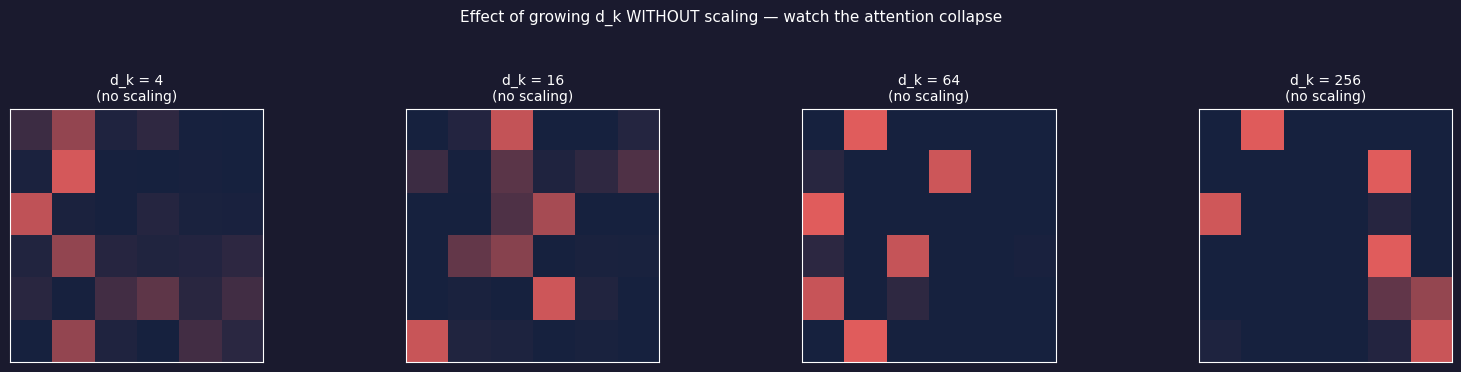

With large d_k and no scaling: one position dominates, gradients vanish.
Now try: change 'scale=False' to 'scale=True' — the pattern evens out.


In [12]:
# ── EXPERIMENT 1: What happens to attention as d_k grows? ─────────────────────
#
# Without scaling, large d_k makes softmax collapse to near-one-hot.
# Try commenting out the scaling and see how attention weights change.

def attention_with_optional_scale(Q, K, V, scale=True):
    d_k = Q.shape[-1]
    scores = Q @ K.T
    if scale:
        scores = scores / np.sqrt(d_k)
    return softmax(scores, axis=-1)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
fig.patch.set_facecolor('#1a1a2e')
cmap = LinearSegmentedColormap.from_list('attn', ['#16213e', '#e05c5c'])

for ax, d_k_exp in zip(axes, [4, 16, 64, 256]):
    Q_exp = np.random.randn(6, d_k_exp)
    K_exp = np.random.randn(6, d_k_exp)
    V_exp = np.random.randn(6, d_k_exp)
    
    w_unscaled = attention_with_optional_scale(Q_exp, K_exp, V_exp, scale=False)
    
    ax.set_facecolor('#16213e')
    ax.imshow(w_unscaled, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(f'd_k = {d_k_exp}\n(no scaling)', color='white', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Effect of growing d_k WITHOUT scaling — watch the attention collapse',
             color='white', fontsize=11, y=1.05)
plt.tight_layout()
plt.savefig('scaling_experiment.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("With large d_k and no scaling: one position dominates, gradients vanish.")
print("Now try: change 'scale=False' to 'scale=True' — the pattern evens out.")

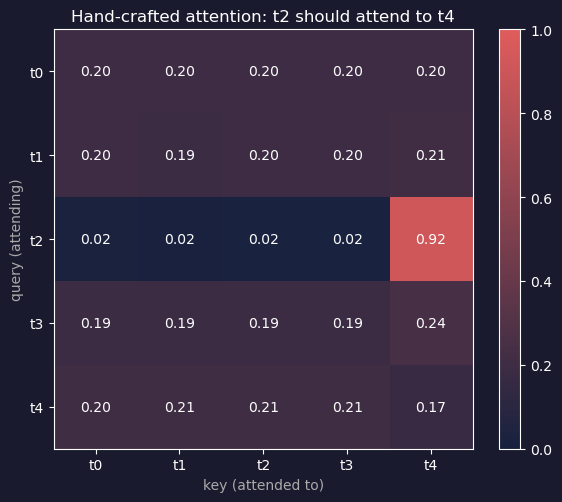

Row 2 attention weights: [0.024 0.018 0.021 0.021 0.917]
Highest weight in row 2 is at position: 4 (expected: 4)


In [13]:
# ── EXPERIMENT 2: Hand-craft a Q and K to force specific attention ─────────────
#
# We have 5 tokens. Make token 2 (index 2) attend strongly to token 4 (index 4).
# We do this by making Q[2] and K[4] very similar.

n_exp = 5
d_exp = 4

Q_hand = np.random.randn(n_exp, d_exp) * 0.1   # small random baseline
K_hand = np.random.randn(n_exp, d_exp) * 0.1
V_hand = np.random.randn(n_exp, d_exp)

# Force Q[2] to be very similar to K[4]
shared_vector = np.array([2.0, -1.5, 1.0, 0.5])
Q_hand[2] = shared_vector
K_hand[4] = shared_vector

_, w_hand = scaled_dot_product_attention(Q_hand, K_hand, V_hand)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')
cmap = LinearSegmentedColormap.from_list('attn', ['#16213e', '#e05c5c'])
im = ax.imshow(w_hand, cmap=cmap, vmin=0, vmax=1)
ax.set_xticks(range(n_exp))
ax.set_yticks(range(n_exp))
ax.set_xticklabels([f't{i}' for i in range(n_exp)], color='white')
ax.set_yticklabels([f't{i}' for i in range(n_exp)], color='white')
ax.set_title('Hand-crafted attention: t2 should attend to t4', color='white')
ax.set_xlabel('key (attended to)', color='#aaa')
ax.set_ylabel('query (attending)', color='#aaa')
for i in range(n_exp):
    for j in range(n_exp):
        ax.text(j, i, f"{w_hand[i,j]:.2f}", ha='center', va='center',
                color='white', fontsize=10)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('handcrafted_attention.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print(f"Row 2 attention weights: {np.round(w_hand[2], 3)}")
print(f"Highest weight in row 2 is at position: {w_hand[2].argmax()} (expected: 4)")

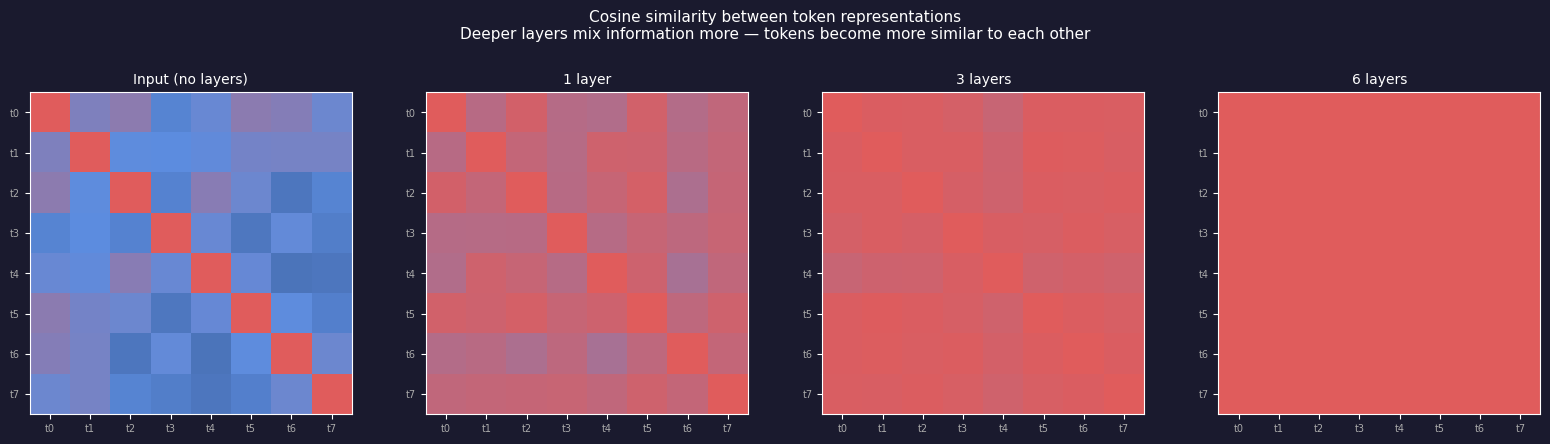

In [14]:
# ── EXPERIMENT 3: Stacking layers — how representations evolve ─────────────────
#
# Run the same input through 1, 3, and 6 encoder layers.
# Watch how the representation changes (measured by cosine similarity between tokens).

def cosine_sim_matrix(X):
    """Pairwise cosine similarity between rows of X."""
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    X_normed = X / (norms + 1e-8)
    return X_normed @ X_normed.T

d_exp  = 32
h_exp  = 4
ff_exp = 128
n_exp  = 8

X_base = np.random.randn(n_exp, d_exp)

enc_1 = TransformerEncoder(d_model=d_exp, h=h_exp, d_ff=ff_exp, n_layers=1)
enc_3 = TransformerEncoder(d_model=d_exp, h=h_exp, d_ff=ff_exp, n_layers=3)
enc_6 = TransformerEncoder(d_model=d_exp, h=h_exp, d_ff=ff_exp, n_layers=6)

X_1 = enc_1.forward(X_base.copy())
X_3 = enc_3.forward(X_base.copy())
X_6 = enc_6.forward(X_base.copy())

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor('#1a1a2e')
cmap = LinearSegmentedColormap.from_list('sim', ['#16213e', '#5c8de0', '#e05c5c'])
token_labels = [f't{i}' for i in range(n_exp)]

for ax, (X_plot, title) in zip(axes, [
    (X_base, 'Input (no layers)'),
    (X_1,    '1 layer'),
    (X_3,    '3 layers'),
    (X_6,    '6 layers'),
]):
    sim = cosine_sim_matrix(X_plot)
    ax.set_facecolor('#16213e')
    ax.imshow(sim, cmap=cmap, vmin=-1, vmax=1)
    ax.set_title(title, color='white', fontsize=10)
    ax.set_xticks(range(n_exp))
    ax.set_yticks(range(n_exp))
    ax.set_xticklabels(token_labels, color='#aaa', fontsize=7)
    ax.set_yticklabels(token_labels, color='#aaa', fontsize=7)

plt.suptitle('Cosine similarity between token representations\n'
             'Deeper layers mix information more — tokens become more similar to each other',
             color='white', fontsize=11, y=1.05)
plt.tight_layout()
plt.savefig('layer_depth_experiment.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## Summary: The Transformer in One Page

| Component | What it does | Key formula |
|-----------|-------------|-------------|
| **Token embedding** | Maps discrete tokens to continuous vectors | Lookup: $x_i = E[\text{token}_i]$ |
| **Positional encoding** | Injects order information | $PE_{(pos,2i)} = \sin(pos / 10000^{2i/d})$ |
| **Scaled dot-product attention** | Each token gathers info from relevant others | $\text{softmax}(QK^T/\sqrt{d_k})V$ |
| **Multi-head attention** | Run $h$ attention heads in parallel, each in its own subspace | $\text{Concat}(\text{head}_1,...,\text{head}_h)W^O$ |
| **Residual connections** | Direct gradient path; sublayer learns corrections only | $x + \text{Sublayer}(x)$ |
| **Layer normalisation** | Stabilises activations per token | $\gamma \cdot (x-\mu)/\sigma + \beta$ |
| **Feed-forward network** | Per-token MLP; processes gathered information | $\text{ReLU}(xW_1+b_1)W_2+b_2$ |
| **Causal mask** | Prevents decoder from seeing future tokens | Upper-triangular $-\infty$ before softmax |

**The key insight:** instead of compressing all past information into a fixed-size vector (RNN), every token maintains its own representation and can attend directly to every other token. This trades the sequential bottleneck for a quadratic cost in sequence length ($O(n^2)$ attention) — which is why long-context models are expensive, and why work like FlashAttention and sparse attention exists.

---

## Further reading

- **Original paper**: Vaswani et al. (2017), "Attention Is All You Need" — https://arxiv.org/abs/1706.03762
- **Illustrated Transformer**: Jay Alammar's visual walkthrough — https://jalammar.github.io/illustrated-transformer/
- **Annotated transformer**: Harvard NLP group, full PyTorch implementation with inline commentary
- **Flash Attention**: Dao et al. (2022) — how to compute attention in $O(n)$ memory
- **RoPE**: Rotary Position Embedding — the modern alternative to sinusoidal encoding, used in LLaMA/Mistral